# Experimento 1: Validación de cinemática inversa

Compara las velocidades angulares **comandadas** a cada rueda (salida de `omni_odometry_node`, ec. 20 Taheri)
contra las velocidades **reales** medidas por los encoders del simulador.

Se envían consignas de velocidad constante para cada GDL por separado:
- $v_x$ puro — avance frontal
- $v_y$ puro — desplazamiento lateral
- $\omega_z$ puro — rotación en el lugar

## Configuración

In [1]:
from pathlib import Path

# ── Bag a analizar ─────────────────────────────────────────────────────────────
BAG_PATH = Path("01_cinematica_inversa")

# ── Parámetros del robot ───────────────────────────────────────────────────────
WHEEL_RADIUS  = 0.05   # m
TICKS_PER_REV = 500    # ticks/rev
WHEEL_NAMES   = ["fl", "fr", "rl", "rr"]   # orden en /robot/encoders

# ── Segmentos de interés ───────────────────────────────────────────────────────
# Definí manualmente los intervalos de cada movimiento.
# Dejá SEGMENTS = None para ver toda la grabación sin cortes.
# Tip: corré la celda "Inspeccioná cmd_vel" para ver los timestamps exactos.
SEGMENTS = None
# SEGMENTS = [
#     {"label": "vx puro",  "t_start": 2.0, "t_end": 12.0},
#     {"label": "vy puro",  "t_start": 15.0, "t_end": 25.0},
#     {"label": "wz puro",  "t_start": 28.0, "t_end": 38.0},
# ]

# ── Estilo de plots ────────────────────────────────────────────────────────────
COLOR_COMMANDED = "steelblue"
COLOR_REAL      = "tomato"
COLOR_ODOMETRY  = "steelblue"
COLOR_GT        = "tomato"
SEGMENT_COLORS  = ["#e8f4f8", "#fef9e7", "#eafaf1", "#fdf2f8"]  # fondos alternados

## Carga de la bag

In [2]:
from rosbags.rosbag2 import Reader
from rosbags.typesys import Stores, get_typestore, get_types_from_msg

# Tipos estándar ROS2 Humble + tipos custom de robmovil_msgs
typestore = get_typestore(Stores.ROS2_HUMBLE)
typestore.register(get_types_from_msg(
    "std_msgs/Header header\nint32[] ticks",
    "robmovil_msgs/msg/MultiEncoderTicks"
))
typestore.register(get_types_from_msg(
    "float32 range\nfloat32 bearing",
    "robmovil_msgs/msg/Landmark"
))
typestore.register(get_types_from_msg(
    "std_msgs/Header header\nrobmovil_msgs/msg/Landmark[] landmarks",
    "robmovil_msgs/msg/LandmarkArray"
))

def read_topic(reader: Reader, topic: str) -> list:
    """Retorna lista de (timestamp_sec, msg) para el tópico dado."""
    connections = [c for c in reader.connections if c.topic == topic]
    return [
        (timestamp_ns * 1e-9, typestore.deserialize_cdr(raw, conn.msgtype))
        for conn, timestamp_ns, raw in reader.messages(connections=connections)
    ]

with Reader(BAG_PATH) as reader:
    print(f"{'Tópico':<52} {'Tipo':<42} Mensajes")
    print("-" * 100)
    for conn in reader.connections:
        print(f"{conn.topic:<52} {conn.msgtype:<42} {conn.msgcount}")

    raw_cmd_vel      = read_topic(reader, "/robot/cmd_vel")
    raw_wheel_fl     = read_topic(reader, "/robot/front_left_wheel/cmd_vel")
    raw_wheel_fr     = read_topic(reader, "/robot/front_right_wheel/cmd_vel")
    raw_wheel_rl     = read_topic(reader, "/robot/rear_left_wheel/cmd_vel")
    raw_wheel_rr     = read_topic(reader, "/robot/rear_right_wheel/cmd_vel")
    raw_encoders     = read_topic(reader, "/robot/encoders")
    raw_odometry     = read_topic(reader, "/robot/odometry")
    raw_ground_truth = read_topic(reader, "/robot/ground_truth")

Tópico                                               Tipo                                       Mensajes
----------------------------------------------------------------------------------------------------
/robot/cmd_vel                                       geometry_msgs/msg/Twist                    16
/goal_pose                                           geometry_msgs/msg/PoseStamped              0
/rosout                                              rcl_interfaces/msg/Log                     14
/robot/rear_left_wheel/cmd_vel                       std_msgs/msg/Float64                       16
/tf                                                  tf2_msgs/msg/TFMessage                     34982
/robot/odometry                                      nav_msgs/msg/Odometry                      2836
/initialpose                                         geometry_msgs/msg/PoseWithCovarianceStamped 0
/clock                                               rosgraph_msgs/msg/Clock                    2

## Construcción de DataFrames

In [3]:
import pandas as pd
import numpy as np

# Tiempo de referencia: primer mensaje de cmd_vel
t_origin = raw_cmd_vel[0][0]

def elapsed(timestamp_sec: float) -> float:
    return timestamp_sec - t_origin

# ── Consignas de velocidad de plataforma ───────────────────────────────────────
df_cmd_vel = pd.DataFrame([
    {"t": elapsed(t), "vx": msg.linear.x, "vy": msg.linear.y, "wz": msg.angular.z}
    for t, msg in raw_cmd_vel
])

# ── Velocidades angulares comandadas a cada rueda ──────────────────────────────
# Cada tópico tiene el mismo número de mensajes publicados en el mismo callback,
# así que los alineamos por índice en lugar de por timestamp float.
wheel_topics = {
    "fl": raw_wheel_fl,
    "fr": raw_wheel_fr,
    "rl": raw_wheel_rl,
    "rr": raw_wheel_rr,
}
df_wheel_cmd = pd.DataFrame({
    "t":          [elapsed(t) for t, _ in raw_wheel_fl],
    **{
        f"omega_cmd_{name}": [msg.data for _, msg in raw]
        for name, raw in wheel_topics.items()
    }
})

# ── Velocidades reales de rueda desde encoders (ticks → rad/s) ─────────────────
df_encoders = pd.DataFrame([
    {"t": elapsed(t), **{f"ticks_{name}": int(msg.ticks[i]) for i, name in enumerate(WHEEL_NAMES)}}
    for t, msg in raw_encoders
])
dt = df_encoders["t"].diff()
for name in WHEEL_NAMES:
    delta_ticks   = df_encoders[f"ticks_{name}"].diff()
    delta_angle   = delta_ticks * (2 * np.pi / TICKS_PER_REV)   # rad
    df_encoders[f"omega_real_{name}"] = delta_angle / dt          # rad/s
df_encoders = df_encoders.dropna()

# ── Odometría (/robot/odometry) ───────────────────────────────────────────────
df_odometry = pd.DataFrame([
    {"t":  elapsed(t),
     "vx": msg.twist.twist.linear.x,
     "vy": msg.twist.twist.linear.y,
     "wz": msg.twist.twist.angular.z,
     "x":  msg.pose.pose.position.x,
     "y":  msg.pose.pose.position.y}
    for t, msg in raw_odometry
])

# ── Ground truth del simulador (/robot/ground_truth) ──────────────────────────
df_ground_truth = pd.DataFrame([
    {"t":  elapsed(t),
     "vx": msg.twist.twist.linear.x,
     "vy": msg.twist.twist.linear.y,
     "wz": msg.twist.twist.angular.z,
     "x":  msg.pose.pose.position.x,
     "y":  msg.pose.pose.position.y}
    for t, msg in raw_ground_truth
])

print(f"cmd_vel:      {len(df_cmd_vel):>5} msgs  |  t = [{df_cmd_vel.t.min():.1f}, {df_cmd_vel.t.max():.1f}] s")
print(f"wheel_cmd:    {len(df_wheel_cmd):>5} msgs  |  t = [{df_wheel_cmd.t.min():.1f}, {df_wheel_cmd.t.max():.1f}] s")
print(f"encoders:     {len(df_encoders):>5} msgs  |  t = [{df_encoders.t.min():.1f}, {df_encoders.t.max():.1f}] s")
print(f"odometry:     {len(df_odometry):>5} msgs  |  t = [{df_odometry.t.min():.1f}, {df_odometry.t.max():.1f}] s")

cmd_vel:         16 msgs  |  t = [0.0, 57.0] s
wheel_cmd:       16 msgs  |  t = [-0.1, 57.0] s
encoders:      2835 msgs  |  t = [-20.5, 73.9] s
odometry:      2836 msgs  |  t = [-20.5, 73.9] s


## Inspeccioná cmd_vel (para definir SEGMENTS)

In [4]:
# Muestra cada cambio de consigna con su timestamp — útil para definir SEGMENTS arriba.
transitions = df_cmd_vel[
    (df_cmd_vel[["vx","vy","wz"]].diff().abs() > 0.001).any(axis=1)
]
print("Cambios de cmd_vel detectados:")
print(transitions.to_string(index=False))

Cambios de cmd_vel detectados:
        t  vx  vy  wz
48.005905 0.0 0.3 0.0


## Helpers de visualización

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def shade_segments(ax, segments, colors=SEGMENT_COLORS):
    """Dibuja fondos de color y etiquetas para cada segmento en el eje dado."""
    if segments is None:
        return
    for i, seg in enumerate(segments):
        color = colors[i % len(colors)]
        ax.axvspan(seg["t_start"], seg["t_end"], alpha=0.4, color=color, zorder=0)
        ax.axvline(seg["t_start"], color="gray", linewidth=0.8, linestyle="--", zorder=1)
        ax.text(
            (seg["t_start"] + seg["t_end"]) / 2, ax.get_ylim()[1],
            seg["label"], ha="center", va="top", fontsize=7, color="dimgray"
        )

def apply_xlim(ax, segments, padding=0.5):
    """Restringe el eje x al rango cubierto por los segmentos definidos."""
    if segments is None:
        return
    t_min = min(s["t_start"] for s in segments) - padding
    t_max = max(s["t_end"]   for s in segments) + padding
    ax.set_xlim(t_min, t_max)

def slice_df(df: pd.DataFrame, segments) -> pd.DataFrame:
    """Filtra el DataFrame a las filas dentro de algún segmento definido."""
    if segments is None:
        return df
    mask = pd.concat([
        (df["t"] >= seg["t_start"]) & (df["t"] <= seg["t_end"])
        for seg in segments
    ], axis=1).any(axis=1)
    return df[mask]

## Cinemática inversa: ω comandada vs ω real por rueda

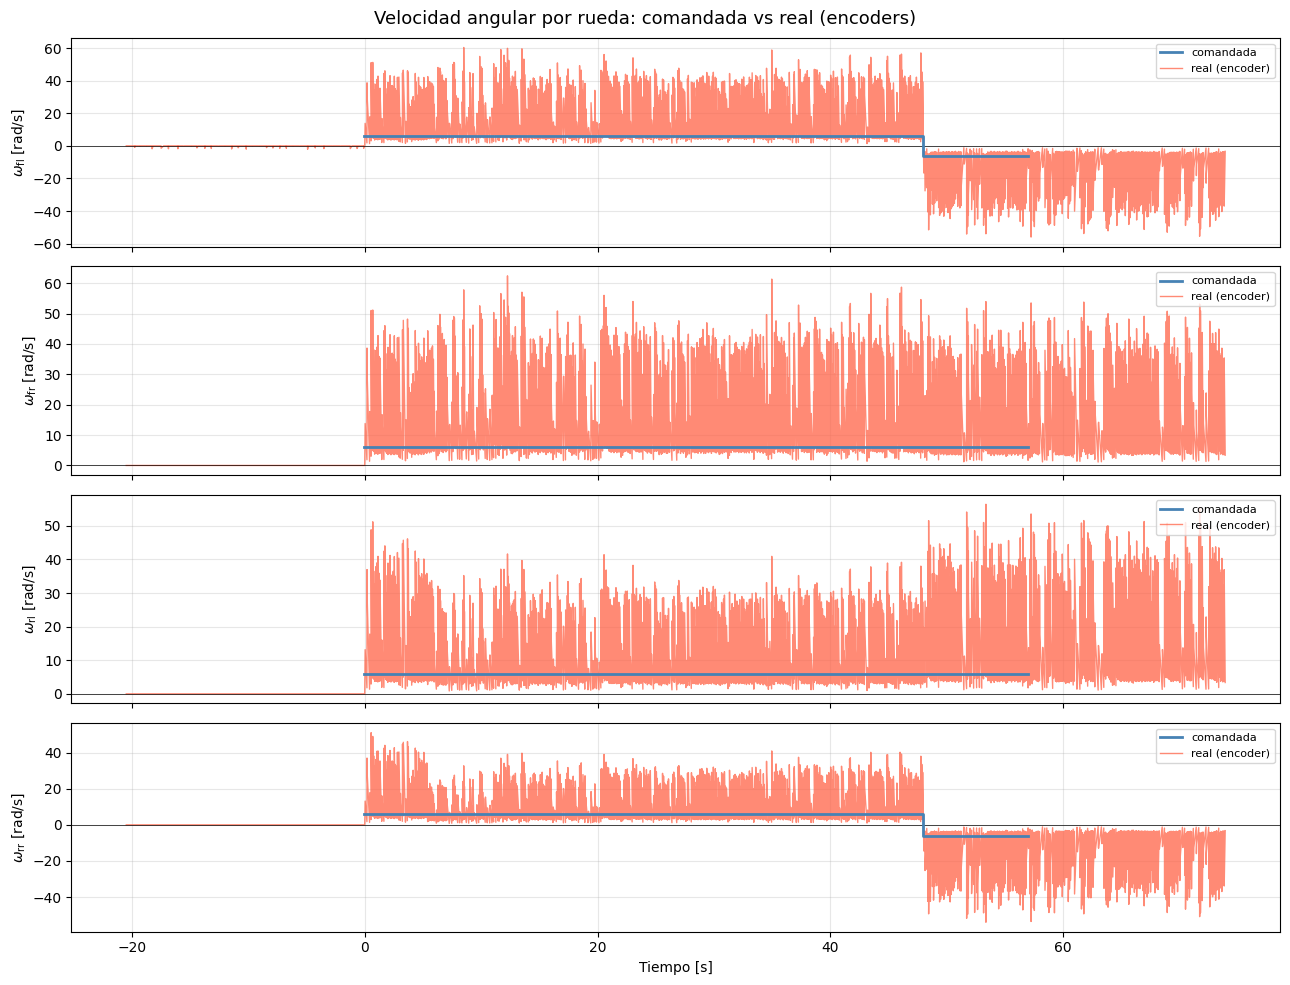

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle("Velocidad angular por rueda: comandada vs real (encoders)", fontsize=13)

for ax, wheel_name in zip(axes, WHEEL_NAMES):
    ax.step(
        df_wheel_cmd["t"], df_wheel_cmd[f"omega_cmd_{wheel_name}"],
        where="post", color=COLOR_COMMANDED, label="comandada", linewidth=2, zorder=3
    )
    ax.plot(
        df_encoders["t"], df_encoders[f"omega_real_{wheel_name}"],
        color=COLOR_REAL, alpha=0.75, label="real (encoder)", linewidth=1, zorder=2
    )
    ax.set_ylabel(f"$\\omega_{{\\mathrm{{{wheel_name}}}}}$ [rad/s]")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
    shade_segments(ax, SEGMENTS)
    apply_xlim(ax, SEGMENTS)

axes[-1].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

## Consigna vs velocidad odométrica (cinemática directa)

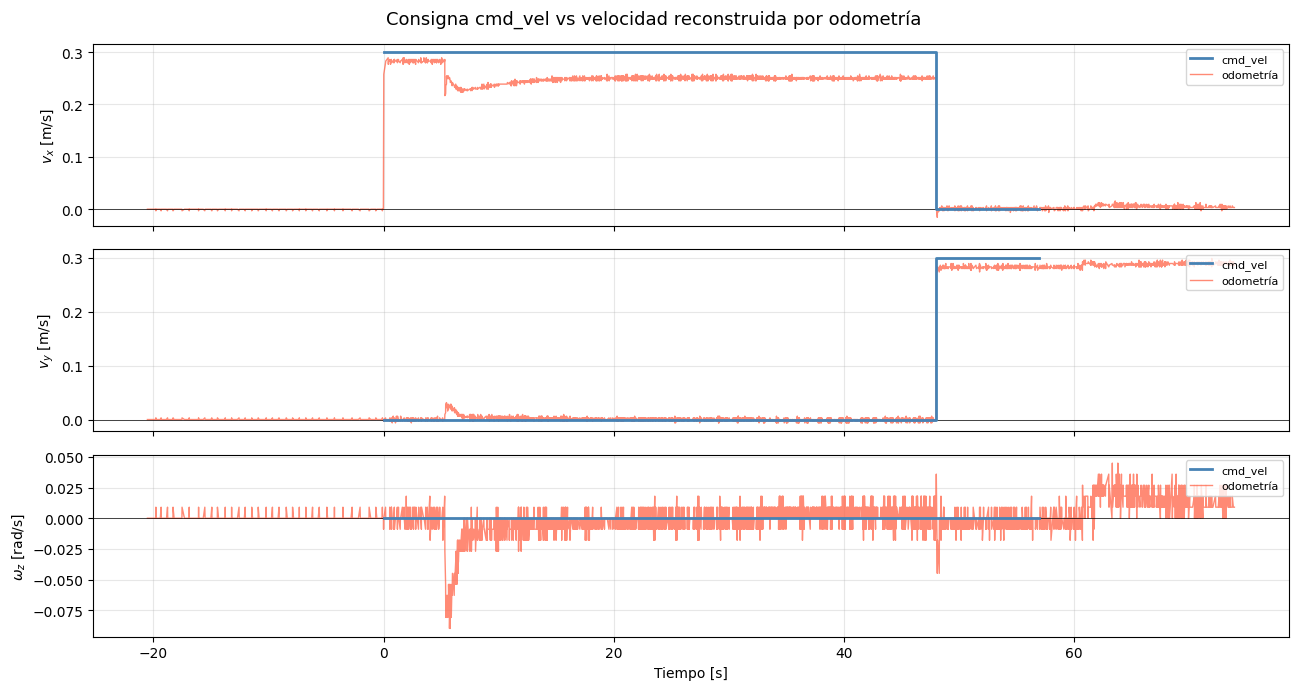

In [7]:
PLATFORM_DOFS = [
    ("vx", "$v_x$ [m/s]"),
    ("vy", "$v_y$ [m/s]"),
    ("wz", "$\\omega_z$ [rad/s]"),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
fig.suptitle("Consigna cmd_vel vs velocidad reconstruida por odometría", fontsize=13)

for ax, (dof, ylabel) in zip(axes, PLATFORM_DOFS):
    ax.step(
        df_cmd_vel["t"], df_cmd_vel[dof],
        where="post", color=COLOR_COMMANDED, label="cmd_vel", linewidth=2, zorder=3
    )
    ax.plot(
        df_odometry["t"], df_odometry[dof],
        color=COLOR_REAL, alpha=0.75, label="odometría", linewidth=1, zorder=2
    )
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="k", linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
    shade_segments(ax, SEGMENTS)
    apply_xlim(ax, SEGMENTS)

axes[-1].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

## Trayectoria xy: odometría vs ground truth

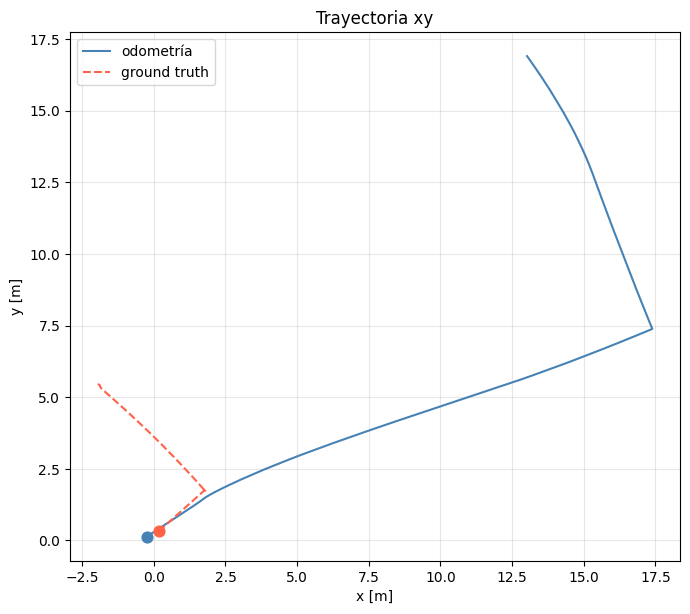

In [8]:
odom_sliced = slice_df(df_odometry,     SEGMENTS)
gt_sliced   = slice_df(df_ground_truth, SEGMENTS)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(odom_sliced["x"], odom_sliced["y"], color=COLOR_ODOMETRY, label="odometría", linewidth=1.5)
ax.plot(gt_sliced["x"],   gt_sliced["y"],   color=COLOR_GT, linestyle="--", label="ground truth", linewidth=1.5)
ax.scatter(odom_sliced["x"].iloc[0], odom_sliced["y"].iloc[0], color=COLOR_ODOMETRY, s=60, zorder=5)
ax.scatter(gt_sliced["x"].iloc[0],   gt_sliced["y"].iloc[0],   color=COLOR_GT,       s=60, zorder=5)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Trayectoria xy")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()